In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

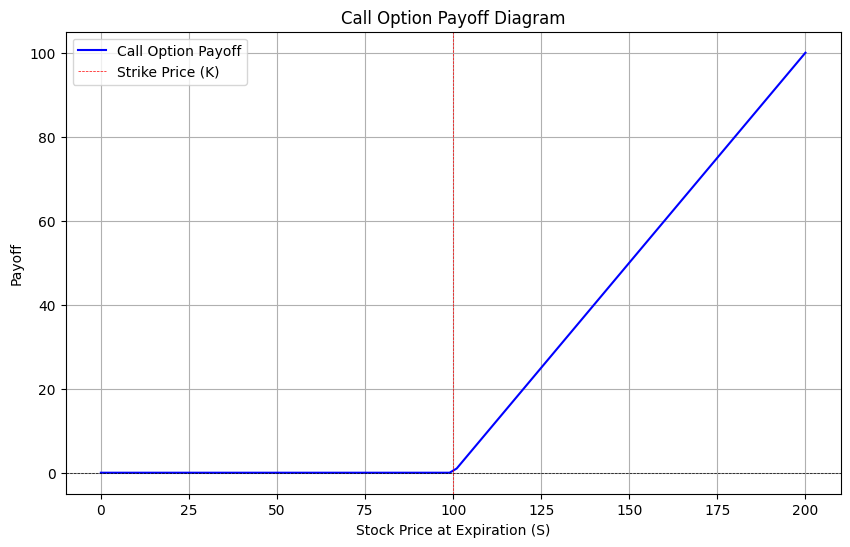

In [6]:
## Call option payoff diagram

def call_option_payoff(S, K):
    return np.maximum(S - K, 0)

S = np.linspace(0, 200, 100)
K = 100
payoff = call_option_payoff(S, K)   

plt.figure(figsize=(10, 6))
plt.plot(S, payoff, label='Call Option Payoff', color='blue')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(K, color='red', lw=0.5, ls='--', label='Strike Price (K)')
plt.title('Call Option Payoff Diagram')
plt.xlabel('Stock Price at Expiration (S)')
plt.ylabel('Payoff')
plt.legend()
plt.grid()



In [7]:

# 2-step binomial model for a European call

def european_call_binomial(S0, K, r, u, d, dt):
    # risk-neutral probability
    p = (1 + r * dt - d) / (u - d)

    # stock prices at maturity (t=2)
    Suu = S0 * u * u
    Sud = S0 * u * d
    Sdd = S0 * d * d

    # option payoffs at t=2
    Cu = max(Suu - K, 0)
    Cm = max(Sud - K, 0)
    Cd = max(Sdd - K, 0)

    # step back to t=1
    C_u1 = (p * Cu + (1 - p) * Cm) / (1 + r * dt)
    C_d1 = (p * Cm + (1 - p) * Cd) / (1 + r * dt)

    # step back to t=0
    C0 = (p * C_u1 + (1 - p) * C_d1) / (1 + r * dt)
    return C0

# example usage
S0 = 100
K = 100
r = 0.05
u = 1.1
d = 0.9

dt = 0.5  # half-year steps
price = european_call_binomial(S0, K, r, u, d, dt)
print(f"2-step binomial European call price: {price:.4f}")

2-step binomial European call price: 7.8079
